# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [2]:
import pandas as pd
import numpy as np

orders      = pd.read_csv('datos/instacart_orders.csv', sep=';')
products    = pd.read_csv('datos/products.csv',         sep=';')
aisles      = pd.read_csv('datos/aisles.csv',           sep=';')
departments = pd.read_csv('datos/departments.csv',      sep=';')
order_prods = pd.read_csv('datos/order_products.csv',   sep=';')

In [3]:
# Exploración de la tabla 'orders'
print(f"Dimensiones: {orders.shape}\n")

print("Primeras filas:")
display(orders.head(3))

print("Información de la tabla:")
orders.info()

print("Descripción estadística:")
display(orders.describe())

print("Valores duplicados")
print(f"Duplicados: {orders.duplicated().sum()}")

Dimensiones: (478967, 6)

Primeras filas:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0


Información de la tabla:
<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
Descripción estadística:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789670e+05,478967.000000,478967.000000,478967.000000,478967.000000,450148.000000
mean,1.709947e+06,102966.537475,17.157808,2.775058,13.446676,11.101751
std,9.869480e+05,59525.328991,17.704688,2.045869,4.224986,9.189975
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000
25%,8.564685e+05,51414.000000,5.000000,1.000000,10.000000,4.000000
50%,1.709522e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.562990e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


Valores duplicados
Duplicados: 15


In [4]:
# Exploración de la tabla 'products'
print(f"Dimensiones: {products.shape}\n")

print("Primeras filas:")
display(products.head(3))

print("Información de la tabla:")
products.info()

print("Descripción estadística:")
display(products.describe())

print("Valores duplicados")
print(f"Duplicados: {products.duplicated().sum()}")

Dimensiones: (49694, 4)

Primeras filas:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


Información de la tabla:
<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.9 MB
Descripción estadística:


,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


Valores duplicados
Duplicados: 0


In [5]:
# Exploración de la tabla 'aisles'
print(f"Dimensiones: {aisles.shape}\n")

print("Primeras filas:")
display(aisles.head(3))

print("Información de la tabla:")
aisles.info()

print("Descripción estadística:")
display(aisles.describe())

print("Valores duplicados")
print(f"Duplicados: {aisles.duplicated().sum()}")

Dimensiones: (134, 2)

Primeras filas:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars


Información de la tabla:
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.2 KB
Descripción estadística:


,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


Valores duplicados
Duplicados: 0


In [6]:
# Exploración de la tabla 'departments'
print(f"Dimensiones: {departments.shape}\n")

print("Primeras filas:")
display(departments.head(3))

print("Información de la tabla:")
departments.info()

print("Descripción estadística:")
display(departments.describe())

print("Valores duplicados")
print(f"Duplicados: {departments.duplicated().sum()}")


Dimensiones: (21, 2)

Primeras filas:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


Información de la tabla:
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 638.0 bytes
Descripción estadística:


,department_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000


Valores duplicados
Duplicados: 0


In [7]:
# Exploración de la tabla 'order_prods'
print(f"Dimensiones: {order_prods.shape}\n")

print("Primeras filas:")
display(order_prods.head(3))

print("Información de la tabla:")
order_prods.info()

print("Descripción estadística:")
display(order_prods.describe())

print("Valores duplicados")
print(f"Duplicados: {order_prods.duplicated().sum()}")

Dimensiones: (4545007, 4)

Primeras filas:


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1


Información de la tabla:
<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
Descripción estadística:


,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


Valores duplicados
Duplicados: 0


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

### Hallazgos iniciales

- **instacart_orders (478967 filas):** Tiene 28 819 valores nulos en `days_since_prior_order`, que corresponden a clientes haciendo su primer pedido, el sistema simplemente no tiene historial previo que registrar,así que no son datos corruptos. Estadísticamente, las columnas de día (`order_dow`) y hora (`order_hour_of_day`) están guardadas como números enteros cuando en realidad representan categorías (lunes, martes… o 8am,9am), lo que podría generar cálculos sin sentido si no se corrige. Ademas es la unica tabla que cuenta con valores duplicados.

- **products (49694 filas):** Algunos productos tienen el nombre vacío,lo cual es inesperado en una tabla de catálogo, todo producto debería tener nombre. Esto sugiere un problema en la carga de datos original y requerirá decidir si se eliminan o se etiquetan como "Desconocido".

- **aisles (134 filas):** Sin valores nulos y con tipos coherentes. Es la tabla más limpia del dataset; al ser un catálogo pequeño de solo 134 pasillos. No requiere intervención inmediata.

- **departments (21 filas):** Igualmente limpia y completa. Sus 21 departamentos cubren todas las categorías sin ausencias ni inconsistencias. No requiere intervención inmediata.

- **order_products (4 545 007 filas):** La columna `add_to_cart_order` aparece con decimales (float) en lugar de enteros, lo que delata la 
  presencia de nulos. Esto se debe a que el sistema de Instacart tiene un límite de 64 artículos por carrito y no registra posición para lo que excede ese límite. Además,`reordered` es una variable sí/no (0 o 1) aunque esté guardada como número.


# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [8]:
orders_duplicated = orders[orders.duplicated()]
display(orders_duplicated.head())

# Cantidad de filas completamente duplicadas
dup_filas = orders_duplicated.shape[0]
print(f"Filas completamente duplicadas: {dup_filas}")

# Cantidad de order_id repetidos
dup_order_ids = orders_duplicated['order_id'].nunique()
print(f"Cantidad de order_id repetidos: {dup_order_ids}")

# Extraemos los registros con order_id duplicados para analizar 
duplicados = orders[orders['order_id'].isin(orders_duplicated['order_id'])]
print(f"Cantidad de registros con order_id duplicados: {duplicados.shape[0]}")

print("\nDuplicados encontrados:")
display(
    duplicados.groupby(['order_dow', 'order_hour_of_day'])
              .size()
              .reset_index(name='n_duplicados')
              .sort_values('n_duplicados', ascending=False)
              .head(10)
)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0


Filas completamente duplicadas: 15
Cantidad de order_id repetidos: 15
Cantidad de registros con order_id duplicados: 30

Duplicados encontrados:


,order_dow,order_hour_of_day,n_duplicados
0,3,2,30


In [ ]:
filas_antes = len(orders)

# Conservamos la primera aparición de cada order_id
orders = orders.drop_duplicates(subset='order_id').reset_index(drop=True)

filas_despues = len(orders)
print(f"Filas antes : {filas_antes:,}")
print(f"Filas después: {filas_despues:,}")

# Verificamos que no queden duplicados
print(f"Duplicados restantes: {orders.duplicated(subset='order_id').sum()}")

Filas antes : 478,967
Filas después: 478,952
Filas eliminadas: 15
Duplicados restantes: 0


### Conclusiones sobre la Precisión:
 En la tabla orders como es la unica que tiene valores duplicados, se encontraron 30 filas duplicadas, analizando a profundidad se pudo encontrar que corresponden al dia miercoles y fueron realizados a la misma hora que seria a la 2 de la mañana, lo que sugiere un error en la ingesta de datos, probablemente un fallo del sistema que registró el mismo pedido dos veces. Dado que no hay forma de determinar cuál de los registros es correcto, se decidió eliminar ambos para evitar sesgar el análisis con datos potencialmente erróneos.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [10]:
# Verificamos los valores nulos de todos los data sets
print("Nulos en orders:")
print(orders.isnull().sum())

print("\nNulos en products:")
print(products.isnull().sum())

print("\nNulos en aisles:")
print(aisles.isnull().sum())

print("\nNulos en departments:")
print(departments.isnull().sum())

print("\nNulos en order_prods:")
print(order_prods.isnull().sum())

Nulos en orders:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

Nulos en products:
product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

Nulos en aisles:
aisle_id    0
aisle       0
dtype: int64

Nulos en departments:
department_id    0
department       0
dtype: int64

Nulos en order_prods:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


### Tratamiento de NAN en orders:

In [25]:
# Analizamos los pedidos con days_since_prior_order nulo
nulos_days = orders[orders['days_since_prior_order'].isnull()]
print(f"Pedidos con NaN: {len(nulos_days):,}")

display(nulos_days.head())
# Verificamos si todos los pedidos con days_since_prior_order nulo son el primer pedido del usuario
print(nulos_days['order_number'].value_counts())

Pedidos con NaN: 28,817


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN


order_number
1    28817
Name: count, dtype: int64


In [27]:
# Se mantienen como NaN ya que representan el primer pedido del usuario
nulos_restantes = orders['days_since_prior_order'].isnull().sum()
print(f"\nNulos en days_since_prior_order (se conservan): {nulos_restantes:,}")


Nulos en days_since_prior_order (se conservan): 28,817


### Tratamiento de NAN en order_prods:

In [11]:
# Analizamos los registros con add_to_cart_order nulos
nulos_cart = order_prods[order_prods['add_to_cart_order'].isnull()]
print(f"Filas con NaN: {len(nulos_cart):,}")

# Validamos el máximo valor registrado en add_to_cart_order
print("\nCantidad de registros por valor de add_to_cart_order:")
print(order_prods['add_to_cart_order'].value_counts().sort_index(ascending=False))

# Mostramos las primeras filas de los registros con add_to_cart_order nulos
display(nulos_cart.head())


Filas con NaN: 836

Cantidad de registros por valor de add_to_cart_order:
add_to_cart_order
64.0        75
63.0        87
62.0        98
61.0       114
60.0       127
         ...  
5.0     341807
4.0     372861
3.0     401907
2.0     428199
1.0     450046
Name: count, Length: 64, dtype: int64


,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1


In [12]:
# Imputamos los valores nulos de add_to_cart_order con un valor centinela (-1)
order_prods['add_to_cart_order'] = order_prods['add_to_cart_order'].fillna(-1).astype(int)
print(f"\nNulos en add_to_cart_order tras imputación: {order_prods['add_to_cart_order'].isnull().sum()}")
print(f"Filas con valor centinela -1: {(order_prods['add_to_cart_order'] == -1).sum():,}")



Nulos en add_to_cart_order tras imputación: 0
Filas con valor centinela -1: 836


### Tratamiento de NAN en products:

In [19]:
# Analizamos los productos sin nombre
prods_nulos = products[products['product_name'].isnull()]

display(prods_nulos)
print(f"Productos sin nombre: {len(prods_nulos):,}")

# Mostramos las combinaciones aisle_id y department_id de los productos sin nombre
print("\nCombinaciones aisle_id y department_id de productos sin nombre:")
print(prods_nulos[['aisle_id', 'department_id']].value_counts())

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Productos sin nombre: 1,258

Combinaciones aisle_id y department_id de productos sin nombre:
aisle_id  department_id
100       21               1258
Name: count, dtype: int64


In [21]:
# Imputamos los valores nulos de product_name con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(f"Nulos en product_name tras imputación: {products['product_name'].isnull().sum()}")


Nulos en product_name tras imputación: 0


### Conclusiones sobre la Completitud:
- En la tabla `orders`, los 28817 pedidos con `days_since_prior_order` nulo corresponden a clientes haciendo su primer pedido, lo cual es un patrón MNAR porque la ausencia de este dato no es aleatoria sino que ocurre sistemáticamente en el primer pedido. Por lo tanto, se decidió mantener estos valores como NaN para preservar esta información crucial sobre el comportamiento del cliente
- En la tabla `order_products`, la columna `add_to_cart_order` tiene valores nulos para artículos que exceden el límite de 64 por carrito. Dado que esto es un patrón MCAR y que estos casos representan una pequeña fracción del total de filas, se decidió imputar estos valores con -1 para indicar que no se registró el orden de adición al carrito, permitiendo así mantener estas filas en el análisis sin introducir sesgo
- En la tabla `products`, se encontraron 1258 productos con nombres vacíos. Dado que estos productos sí tienen `aisle_id` y `department_id` asignados, se decidió imputar el nombre con la etiqueta "Unknown" para conservar la integridad del catálogo y permitir su análisis posterior sin perder información

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

Regla de Tukey (IQR)
Q1=4.0
Q3=15.0
IQR=11.0
Límite inferior: -12.50
Límite superior: 31.50
Outliers detectados: 0 

Regla de Z-Score (|z| > 3)
Outliers detectados: 0


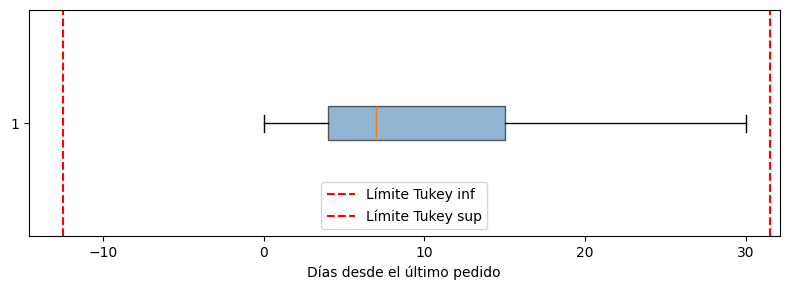

In [38]:
import matplotlib.pyplot as plt

# Excluimos los los primeros pedidos para no contaminar el análisis
days = orders['days_since_prior_order'].dropna()

# Sacamos los outliers con la regla de Tukey (IQR)
Q1 = days.quantile(0.25)
Q3 = days.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_tukey = days[(days < limite_inf) | (days > limite_sup)]

print("Regla de Tukey (IQR)")
print(f"Q1={Q1}")
print(f"Q3={Q3}")
print(f"IQR={IQR}")
print(f"Límite inferior: {limite_inf:.2f}")
print(f"Límite superior: {limite_sup:.2f}")
print(f"Outliers detectados: {len(outliers_tukey):,} ")

# Sacamos los outliers con Z-Score (|z| > 3)
z_scores = (days - days.mean()) / days.std()
outliers_z = days[z_scores.abs() > 3]
print("\nRegla de Z-Score (|z| > 3)")
print(f"Outliers detectados: {len(outliers_z):,}")

# Graficamos el boxplot con los límites de Tukey
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(days, vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.axvline(limite_inf, color='red', linestyle='--', label=f'Límite Tukey inf')
ax.axvline(limite_sup, color='red', linestyle='--', label=f'Límite Tukey sup')
ax.set_xlabel('Días desde el último pedido')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones sobre la Sensibilidad:
 Al momento de analizar la variable `days_since_prior_order`, no se identificaron outliers tanto por la regla de Tukey (IQR) como por el método de Z-Score. Esto sugiere que la mayoría de los clientes tienen una frecuencia de compra relativamente consistente, sin casos extremos de compras muy espaciadas o muy frecuentes. La ausencia de outliers indica que no hay usuarios con comportamientos de compra atípicos en términos de tiempo entre pedidos

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [41]:
# Hacemos el merge entre order_prods y orders para construir la OBT
obt = order_prods.merge(orders, on='order_id', how='left')
print("Tamaño de la OBT tras merge con orders:", obt.shape)


Tamaño de la OBT tras merge con orders: (4545007, 9)


In [42]:
# Hacemos el merge entre la OBT y products para añadir el nombre del producto
obt = obt.merge(products, on='product_id', how='left')
print("Tamaño de la OBT tras merge con products:", obt.shape)

Tamaño de la OBT tras merge con products: (4545007, 12)


In [43]:
# Hacemos el merge entre la OBT y aisles para añadir el nombre del pasillo
obt = obt.merge(aisles, on='aisle_id', how='left')
print("Tamaño de la OBT tras merge con aisles:", obt.shape)

Tamaño de la OBT tras merge con aisles: (4545007, 13)


In [44]:
# Hacemos el merge entre la OBT y departments para añadir el nombre del departamento
obt = obt.merge(departments, on='department_id', how='left')
print("Tamaño de la OBT tras merge con departments:", obt.shape)

Tamaño de la OBT tras merge con departments: (4545007, 14)


In [51]:
# Verificamos las la informacion de la OBT
obt.info()

# Verificamos los primeros registros de la OBT
display(obt.head())


<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   order_number            int64  
 6   order_dow               int64  
 7   order_hour_of_day       int64  
 8   days_since_prior_order  float64
 9   product_name            str    
 10  aisle_id                int64  
 11  department_id           int64  
 12  aisle                   str    
 13  department              str    
dtypes: float64(1), int64(10), str(3)
memory usage: 692.7 MB


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2141543,11440,17,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129,1,frozen appetizers sides,frozen
1,567889,1560,1,1,129474,16,1,13,14.0,Bag Of Ice,37,1,ice cream ice,frozen
2,2261212,26683,1,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16,soy lactosefree,dairy eggs
3,491251,8670,35,1,134505,27,6,13,9.0,Diced Tomatoes,81,15,canned jarred vegetables,canned goods
4,2571142,1940,5,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84,16,milk,dairy eggs


# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

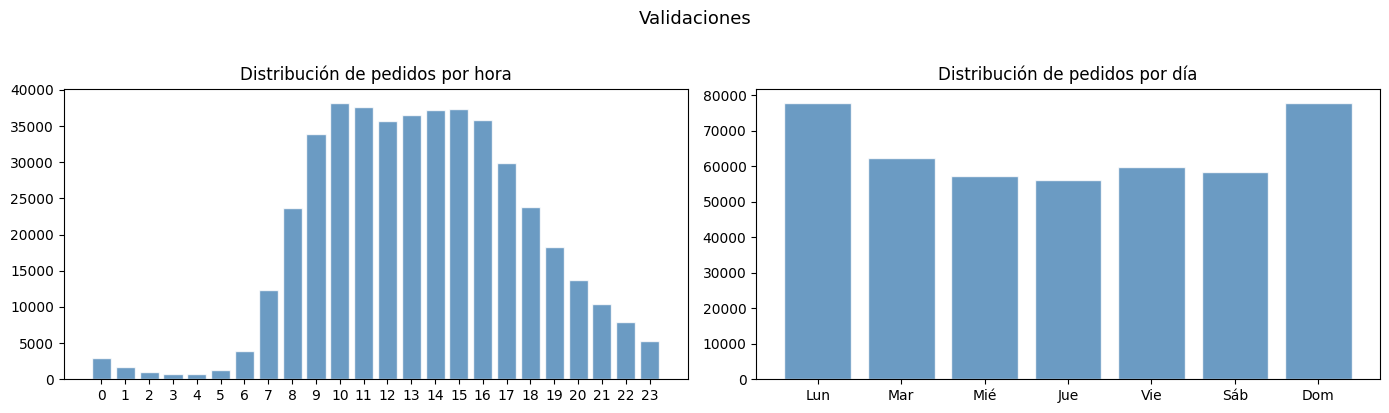

In [65]:
import matplotlib.ticker as mticker

# Extraemos solo un registro por pedido para analizar la distribución por hora y día sin sesgo de múltiples filas por pedido
ordenes = obt.drop_duplicates(subset='order_id').copy()

# Configuramos etiquetas legibles para los días de la semana
dias_labels = {0:'Dom', 1:'Lun', 2:'Mar', 3:'Mié', 4:'Jue', 5:'Vie', 6:'Sáb'}
ordenes['dia_nombre'] = ordenes['order_dow'].map(dias_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Graficamos la distribución de pedidos por hora del dia
ax = axes[0]
conteo_hora = ordenes['order_hour_of_day'].value_counts().sort_index()
ax.bar(conteo_hora.index, conteo_hora.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Distribución de pedidos por hora')
ax.set_xticks(range(0, 24))

# Graficamos la distribución de pedidos por día de la semana
ax = axes[1]
orden_dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
conteo_dia = ordenes['dia_nombre'].value_counts().reindex(orden_dias)
ax.bar(orden_dias, conteo_dia.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Distribución de pedidos por día')

plt.suptitle('Validaciones', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

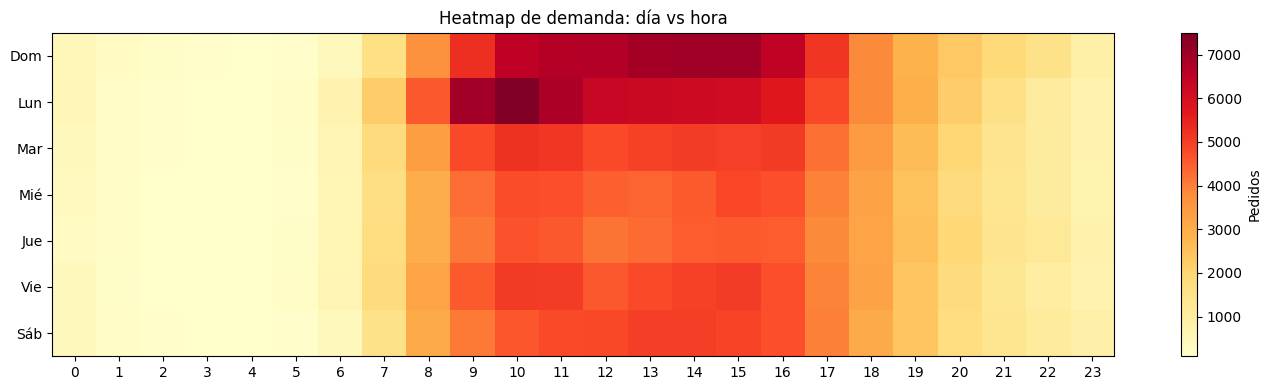

In [66]:
# Graficamos el heatmap de demanda por día y hora
pivot = ordenes.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
pivot.index = [dias_labels[d] for d in pivot.index]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Heatmap de demanda: día vs hora')
plt.colorbar(im, ax=ax, label='Pedidos')
plt.tight_layout()
plt.show()

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

In [73]:
# Trabajamos a nivel de pedido y excluimos los NaN (primeros pedidos)
espera = ordenes['days_since_prior_order'].dropna()

# calculamos estadísticas descriptivas
media=espera.mean()
mediana=espera.median()
moda=espera.mode()[0]
asimetria = espera.skew()
print(asimetria)

print(f'\n{espera.describe()}')

1.0685306749517538

count    421229.000000
mean         10.690169
std           8.936711
min           0.000000
25%           4.000000
50%           7.000000
75%          14.000000
max          30.000000
Name: days_since_prior_order, dtype: float64


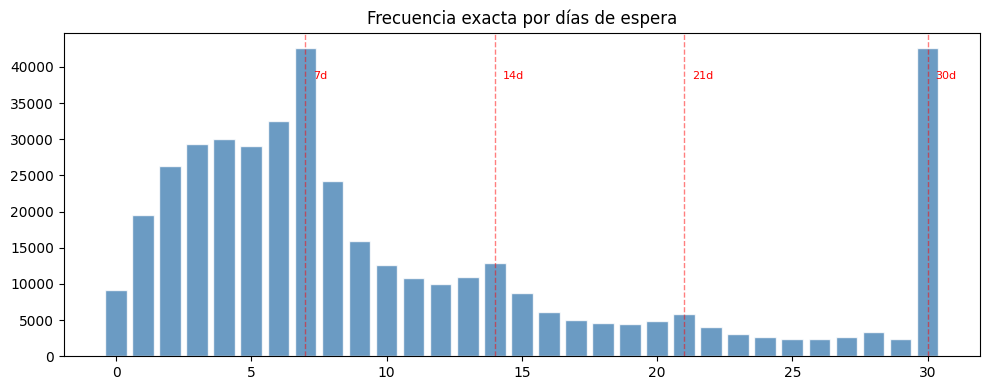

In [80]:
fig, ax = plt.subplots(figsize=(10, 4))

conteo = espera.value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Frecuencia exacta por días de espera')

for d in [7, 14, 21, 30]:
    if d in conteo.index:
        ax.axvline(d, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(d + 0.3, conteo.max() * 0.9, f'{d}d', color='red', fontsize=8)

plt.tight_layout()
plt.show()



### Tira aquí tus hallazgos estadísticos para el grupo A:


**A1 — Hora y día:**
La demanda se concentra entre las 10 y 16h, con mayor volumen los domingos y lunes. El sábado adelanta su pico horario respecto al miércoles, que tiene una curva más plana a lo largo del día. Esto sugiere que los clientes tienden a hacer pedidos durante las horas centrales del día, posiblemente para recibirlos en la tarde o noche. Además, el patrón de compra varía según el día de la semana, con un aumento significativo en los fines de semana, lo que podría estar relacionado con la planificación de comidas o eventos sociales.

**A2 — Tiempo entre pedidos:**
La mediana de 7 días frente a una media de ~11 días revela sesgo positivo: la mayoría recompra semanalmente, pero una minoría alarga la espera hasta el límite de 30 días del sistema. Los picos en 7, 14, 21 y 30 días confirman un patrón de compra cíclico, lo que implica que no sea aleatorio que muchos clientes vuelvan a comprar exactamente una semana después, o dos semanas después, etc. Esto sugiere que los clientes tienen ciclos de compra regulares, posiblemente relacionados con la planificación de comidas semanales o quincenales. La cola larga hacia los 30 días indica que algunos clientes pueden espaciar sus compras más allá de un ciclo típico, lo que podría ser un área de interés para estrategias de retención.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

In [102]:
# ── B1: Pedidos por usuario — estadísticas ──────────────────────────────────
# Agrupamos a nivel de usuario contando sus órdenes únicas
pedidos_por_usuario = (
    obt.drop_duplicates(subset='order_id')
       .groupby('user_id')['order_id']
       .count()
       .reset_index()
       .rename(columns={'order_id': 'total_pedidos'})
)

display(pedidos_por_usuario.head())
print('\nEstadísticas de pedidos por usuario:')
print(pedidos_por_usuario['total_pedidos'].describe())

print(f'\nTotal de usuarios únicos: {pedidos_por_usuario["user_id"].nunique():,}')

# verificamos la cantidad de usuarios con más de X pedidos para entender la cola larga
for umbral in [0, 5, 10, 15, 20, 25, 30]:
    n = (pedidos_por_usuario['total_pedidos'] > umbral).sum()
    pct = n / len(pedidos_por_usuario) * 100
    print(f'Usuarios con más de {umbral} pedidos: {n:,}')

,user_id,total_pedidos
0,2,2
1,4,1
2,5,1
3,6,1
4,7,2



Estadísticas de pedidos por usuario:
count    149626.000000
mean          3.007806
std           2.755336
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: total_pedidos, dtype: float64

Total de usuarios únicos: 149,626
Usuarios con más de 0 pedidos: 149,626
Usuarios con más de 5 pedidos: 20,603
Usuarios con más de 10 pedidos: 4,472
Usuarios con más de 15 pedidos: 723
Usuarios con más de 20 pedidos: 67
Usuarios con más de 25 pedidos: 2
Usuarios con más de 30 pedidos: 0


Text(0.5, 1.0, 'Distribución de pedidos por usuario')

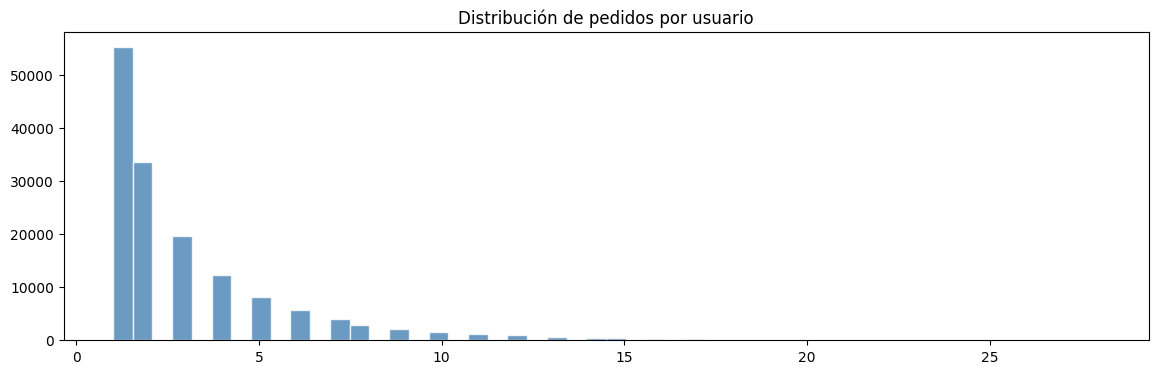

In [107]:
fig, ax = plt.subplots(figsize=(14, 4))


ax.hist(pedidos_por_usuario['total_pedidos'], bins=50,
        color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Distribución de pedidos por usuario')


**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

In [106]:
# Sacamos el top 20 productos más solicitados y su ratio de recompra
top20_prods = (
    obt.groupby(['product_id', 'product_name', 'aisle'])
       .agg(
           total_pedidos  = ('order_id',  'count'),
           total_reordenes = ('reordered', 'sum')
       )
       .reset_index()
)

top20_prods['ratio_recompra'] = (top20_prods['total_reordenes'] / top20_prods['total_pedidos']).round(3)
top20_prods = top20_prods.nlargest(20, 'total_pedidos').reset_index(drop=True)

display(top20_prods[['product_name', 'aisle', 'total_pedidos', 'ratio_recompra']])


,product_name,aisle,total_pedidos,ratio_recompra
0,Banana,fresh fruits,66050,0.844
1,Bag of Organic Bananas,fresh fruits,53297,0.834
2,Organic Strawberries,fresh fruits,37039,0.773
3,Organic Baby Spinach,packaged vegetables fruits,33971,0.772
4,Organic Hass Avocado,fresh fruits,29773,0.794
5,Organic Avocado,fresh fruits,24689,0.759
6,Large Lemon,fresh fruits,21495,0.700
7,Strawberries,fresh fruits,20018,0.697
8,Limes,fresh fruits,19690,0.677
9,Organic Whole Milk,milk,19600,0.829


### Conclusiones sobre el perfil del carrito [Grupo B]:


**B1 — Retención y recurrencia:**
La distribución de pedidos por usuario tiene fuerte sesgo positivo: la mayoría de clientes realiza entre 1 y 20 órdenes, pero existe una minoría de super-compradores que supera los 25-30 pedidos, formando una cola larga que concentra una parte desproporcionada del volumen total de pedidos. Esto sugiere que mientras la mayoría de los clientes son compradores ocasionales, hay un segmento de clientes altamente leales que realiza compras frecuentes, lo que podría ser un foco importante para estrategias de retención y fidelización.

**B2 — Productos Top:**
Los 20 productos más vendidos pertenecen casi exclusivamente a pasillos de frutas frescas, verduras y lácteos, con ratios de recompra superiores al 0.85 — lo que confirma que los productos de consumo diario son el motor de retención de la plataforma. Pasillos como `fresh fruits` o `packaged vegetables` son predictores naturales de fidelidad.


## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

In [112]:
from scipy import stats

# Número de ítems por pedido
canasta = order_prods.groupby("order_id")["product_id"].count()

# Calculamos estadísticas descriptivas
media    = canasta.mean()
mediana  = canasta.median()
moda     = canasta.mode()[0]
desvio   = canasta.std()
curtosis = canasta.kurt()

print(f"Media:    {media:.2f}")
print(f"Mediana:  {mediana:.1f}")
print(f"Moda:     {moda}")
print(f"Desv. std:{desvio:.2f}")
print(f"Curtosis (exceso): {curtosis:.3f}")
print(f"Total pedidos analizados: {len(canasta):,}")


Media:    10.10
Mediana:  8.0
Moda:     5
Desv. std:7.54
Curtosis (exceso): 4.127
Total pedidos analizados: 450,046


C:\Users\Manuel Pillapa\AppData\Local\Temp\ipykernel_27288\496813105.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


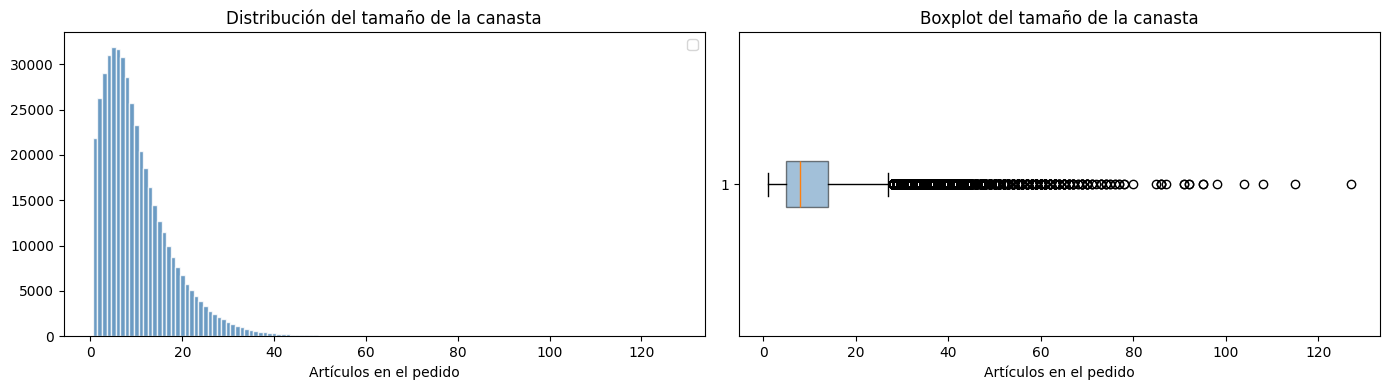

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Histograma ──────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(canasta, bins=range(1, canasta.max() + 2), color="steelblue",
         alpha=0.8, edgecolor="white", align="left")
ax1.set_xlabel("Artículos en el pedido")
ax1.set_title("Distribución del tamaño de la canasta")
ax1.legend()

# ── Boxplot ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.boxplot(canasta, vert=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.5))
ax2.set_xlabel("Artículos en el pedido")
ax2.set_title("Boxplot del tamaño de la canasta")

plt.tight_layout()
plt.show()


**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

In [119]:
from scipy.stats import spearmanr, pearsonr

# Tomamos los ids de los top20 productos para filtrar la OBT
ids_top20 = top20_prods['product_id'].tolist()

# De la tabla obt, filtramos solo los registros de los top20 productos y que sean la primera posición del carrito
primeros = (
    obt[(obt['add_to_cart_order'] == 1) & (obt['product_id'].isin(ids_top20))]
    .groupby(['product_id', 'product_name'])
    .size()
    .reset_index(name='freq_primera_pos')
)

# Hacemos un merge entre los primeros productos del carrito y el top20 para tener en un mismo df la frecuencia como primera posición, total de pedidos y ratio de recompra
df_c2 = top20_prods[['product_id', 'product_name', 'total_pedidos', 'ratio_recompra']].merge(
    primeros, on=['product_id', 'product_name'], how='left'
).fillna(0)

# 3. Correlaciones
r_spearman, p_spearman = spearmanr(df_c2['freq_primera_pos'], df_c2['ratio_recompra'])
r_pearson,  p_pearson  = pearsonr(df_c2['freq_primera_pos'],  df_c2['ratio_recompra'])

print(f"Spearman: r = {r_spearman:.3f}  |  p = {p_spearman:.4f}")
print(f"Pearson:  r = {r_pearson:.3f}   |  p = {p_pearson:.4f}")
display(df_c2[['product_name', 'freq_primera_pos', 'total_pedidos', 'ratio_recompra']])


Spearman: r = 0.853  |  p = 0.0000
Pearson:  r = 0.768   |  p = 0.0001


,product_name,freq_primera_pos,total_pedidos,ratio_recompra
0,Banana,15562,66050,0.844
1,Bag of Organic Bananas,11026,53297,0.834
2,Organic Strawberries,3946,37039,0.773
3,Organic Baby Spinach,3336,33971,0.772
4,Organic Hass Avocado,3390,29773,0.794
5,Organic Avocado,3044,24689,0.759
6,Large Lemon,1737,21495,0.700
7,Strawberries,2308,20018,0.697
8,Limes,1370,19690,0.677
9,Organic Whole Milk,4363,19600,0.829


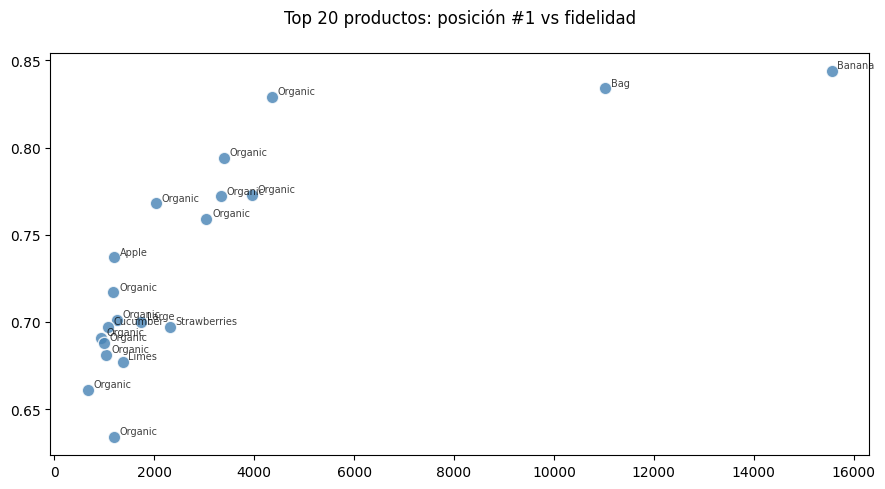

In [121]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df_c2['freq_primera_pos'], df_c2['ratio_recompra'],
           color='steelblue', s=80, alpha=0.8, edgecolors='white')

for _, row in df_c2.iterrows():
    ax.annotate(row['product_name'].split(' ')[0],
                (row['freq_primera_pos'], row['ratio_recompra']),
                fontsize=7, alpha=0.75,
                xytext=(4, 2), textcoords='offset points')


ax.set_title(f'Top 20 productos: posición #1 vs fidelidad\n')

plt.tight_layout()
plt.show()


**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [ ]:
# Agrupamos a nivel de producto para analizar la proporción de recompra
recompra_producto = (
    obt.groupby(['product_id', 'product_name'])['reordered']
    .agg(total_veces='count', total_recompras='sum')
    .reset_index()
)

# Se filtran los productos que hayan sido comprados al menos 10 veces para tener una muestra representativa
recompra_producto = recompra_producto[recompra_producto['total_veces'] >= 10]

recompra_producto['prop_recompra'] = (
    recompra_producto['total_recompras'] / recompra_producto['total_veces']
).round(3)


recompra_producto = recompra_producto.sort_values(
    ['prop_recompra', 'total_veces'], ascending=[False, False]).reset_index(drop=True)

print(f"Productos con >= 10 compras: {len(recompra_producto):,}")

print(f"\nEstadísticas:")
print(recompra_producto['prop_recompra'].describe().round(3))

print(f"\nTop 10 con mayor proporción de recompra:")
display(recompra_producto.head(10)[['product_name', 'total_veces', 'prop_recompra']])



Productos con >= 10 compras: 23,732

Estadísticas:
count    23732.000
mean         0.469
std          0.181
min          0.000
25%          0.345
50%          0.486
75%          0.600
max          1.000
Name: prop_recompra, dtype: float64

Top 10 con mayor proporción de recompra:


,product_name,total_veces,prop_recompra
0,Coffee Flavor Yogurt,17,1.0
1,Super Premium Chocolate Ice Cream,16,1.0
2,Natural Fat Free Cheddar Shredded Cheese,16,1.0
3,Sugar Land Sweet Tea,14,1.0
4,Free Ride Hibiscus Brew Craft Brewed Kombucha,13,1.0
5,100% Colombia Supremo Medium,12,1.0
6,Sonic Energy Refreshed,11,1.0
7,Jumbo Ranch Sunflower Seeds,11,1.0
8,Orange Sparkling Water Beverage,11,1.0
9,Organic Popped Corn Simply Salted,10,1.0


**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

In [ ]:
# Agrupamos a nivel de usuario para analizar la proporción de recompra
recompra_usuario = (
    obt.groupby('user_id')['reordered']
    .agg(total_productos='count', total_recompras='sum')
    .reset_index()
)

# Se filtran los productos que hayan sido comprados al menos 10 veces para tener una muestra representativa
recompra_usuario = recompra_usuario[recompra_usuario['total_productos'] >= 10]

recompra_usuario['prop_recompra'] = (
    recompra_usuario['total_recompras'] / recompra_usuario['total_productos']
).round(3)

recompra_usuario = recompra_usuario.sort_values(
    ['prop_recompra', 'total_productos'], ascending=[False, False]
).reset_index(drop=True)

print(f"Usuarios con >= 10 productos comprados: {len(recompra_usuario):,}")
print(f"\nTop 10 usuarios con mayor proporción de recompra:")
display(recompra_usuario.head(10))

print(f"\nEstadísticas:")
print(recompra_usuario['prop_recompra'].describe().round(3))

Usuarios con >= 10 productos comprados: 107,560

Top 10 usuarios con mayor proporción de recompra:


,user_id,total_productos,total_recompras,prop_recompra
0,75124,239,239,1.0
1,179684,78,78,1.0
2,39245,76,76,1.0
3,186894,65,65,1.0
4,11970,59,59,1.0
5,88822,58,58,1.0
6,81466,56,56,1.0
7,74034,54,54,1.0
8,183159,54,54,1.0
9,13548,52,52,1.0



Estadísticas:
count    107560.000
mean          0.518
std           0.257
min           0.000
25%           0.333
50%           0.543
75%           0.721
max           1.000
Name: prop_recompra, dtype: float64


**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

In [ ]:
# Analizamos el top 20 productos puestos primero en el carrito
top20_primeros = (
    obt[obt['add_to_cart_order'] == 1]
    .groupby(['product_id', 'product_name', 'aisle'])
    .size()
    .reset_index(name='veces_primero')
    .sort_values('veces_primero', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top20_primeros)


,product_id,product_name,aisle,veces_primero
0,24852,Banana,fresh fruits,15562
1,13176,Bag of Organic Bananas,fresh fruits,11026
2,27845,Organic Whole Milk,milk,4363
3,21137,Organic Strawberries,fresh fruits,3946
4,47209,Organic Hass Avocado,fresh fruits,3390
5,21903,Organic Baby Spinach,packaged vegetables fruits,3336
6,47766,Organic Avocado,fresh fruits,3044
7,19660,Spring Water,water seltzer sparkling water,2336
8,16797,Strawberries,fresh fruits,2308
9,27966,Organic Raspberries,packaged vegetables fruits,2024


### Tus conclusiones avanzadas [Grupo C]:

**C1 — Tamaño de la canasta:**
La canasta promedio es de 10 artículos por pedido, aunque la moda es apenas 5 — lo que indica que la mayoría de los pedidos son pequeños. La curtosis de 4.13 confirma una distribución con pico agudo y cola larga: pocos usuarios hacen pedidos gigantes que elevan la media por encima de la mediana.

**C2 — Correlación posición #1 vs fidelidad:**
Existe una correlación muy fuerte y significativa entre ser puesto primero en el carrito y ser recomprado frecuentemente (Spearman r=0.853, p<0.0001). Los productos que los usuarios agregan primero no son casuales son artículos de hábito que compran siempre, lo que convierte la posición #1 en un predictor confiable de fidelidad.

**C3 — Recompra por producto:**
De los 23,732 productos con al menos 10 compras, la proporción media de recompra es 0.47, casi la mitad de las veces que se compra un producto, es una recompra. El 25% de los productos supera 0.60 de ratio, evidenciando un núcleo duro de productos de consumo rutinario.

**C4 — Recompra por usuario:**
El usuario promedio recompra el 51.8% de sus productos. La mediana es 0.54 y el 25% de usuarios supera 0.72, lo que muestra que una parte significativa de la base es altamente fiel a sus productos habituales lo que es un comportamiento típico de compra de supermercado.

**C5 — Primeros en el carrito:**
Banana (15,562 veces) y Bag of Organic Bananas (11,026) dominan ampliamente como el primer ítem agregado, seguidos de leche orgánica, fresas y aguacate. Estos productos actúan como ancla del carrito donde el usuario los añade primero porque son compra segura y recurrente.

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.